# Fake News Detection using Machine Learning

## Project Overview
This project aims to classify news articles as **Fake** or **Real** using Natural Language Processing (NLP) and Machine Learning techniques.

The model is trained using TF-IDF Vectorization and Logistic Regression on a labeled news dataset.

### Technologies Used
- Python
- Pandas
- NumPy
- Scikit-learn
- Matplotlib
- Seaborn

# Install Required Libraries

In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn

## Importing Required Libraries

In this step, all the necessary Python libraries for data processing, visualization, and machine learning are imported.

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Loading the Dataset

The Fake and Real news datasets are loaded using Pandas.

In [5]:
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

## Adding Labels to Dataset

A label column is added to distinguish between fake and real news articles.

- Fake News = 0
- Real News = 1

In [7]:
fake["label"] = 0
true["label"] = 1

## Combining and Shuffling Dataset

Both datasets are merged into a single dataframe and shuffled randomly to improve model training.

In [9]:
data = pd.concat([fake, true], axis=0)

data = data.sample(frac=1).reset_index(drop=True)

data.head()

,title,text,subject,date,label
0,Cheerleading Assassination: Are Hollywood and ...,21st Century Wire says Everyone has the right ...,US_News,"January 24, 2017",0
1,LET THE REPARATIONS BEGIN: Rahm Emanuel Uses $...,"We do this not because it s legally required,...",politics,"May 15, 2015",0
2,"QUESTION: Since Paris Terror Attacks, How Musl...",The answer to this question should shock every...,politics,"Feb 16, 2016",0
3,Kuwait court sentences MPs to jail terms for s...,KUWAIT (Reuters) - A Kuwaiti court handed seve...,worldnews,"November 27, 2017",1
4,"Al Gore says Trump driving, not weakening, cli...",LONDON (Reuters) - Former U.S. Vice President ...,politicsNews,"August 11, 2017",1


## Selecting Important Columns

Only the news text and label columns are selected for model training.

In [11]:
data = data[["text", "label"]]

data.head()

,text,label
0,21st Century Wire says Everyone has the right ...,0
1,"We do this not because it s legally required,...",0
2,The answer to this question should shock every...,0
3,KUWAIT (Reuters) - A Kuwaiti court handed seve...,1
4,LONDON (Reuters) - Former U.S. Vice President ...,1


## Dataset Information and Null Values

The dataset structure and missing values are checked before preprocessing.

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    44898 non-null  object
 1   label   44898 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 701.7+ KB


In [15]:
data.isnull().sum()

text     0
label    0
dtype: int64

## Data Visualization

A count plot is created to visualize the distribution of fake and real news articles.

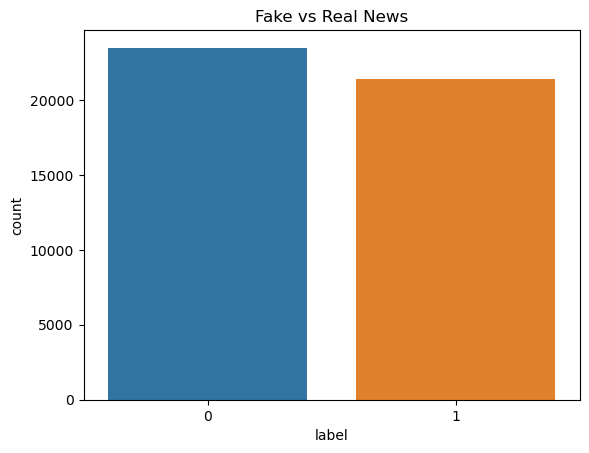

In [17]:
sns.countplot(x='label', data=data)
plt.title("Fake vs Real News")
plt.show()

## Splitting the Dataset

The dataset is divided into training and testing sets.

- Training Data: 80%
- Testing Data: 20%

In [19]:
X = data["text"]
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Text Vectorization using TF-IDF

TF-IDF Vectorization converts text data into numerical format so that it can be used by machine learning algorithms.

In [21]:
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

## Training the Machine Learning Model

Logistic Regression is used to train the fake news classification model.

In [23]:
model = LogisticRegression()

model.fit(X_train_vec, y_train)

LogisticRegression()

## Predicting News Categories

The trained model predicts whether news articles are fake or real.

In [25]:
y_pred = model.predict(X_test_vec)

## Evaluating Model Accuracy

The accuracy score is calculated to measure the model's performance.

In [27]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9838530066815144


## Classification Report

The classification report provides precision, recall, and F1-score for the model.

In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      4685
           1       0.98      0.98      0.98      4295

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980



## Confusion Matrix

A confusion matrix is visualized to analyze correct and incorrect predictions made by the model.

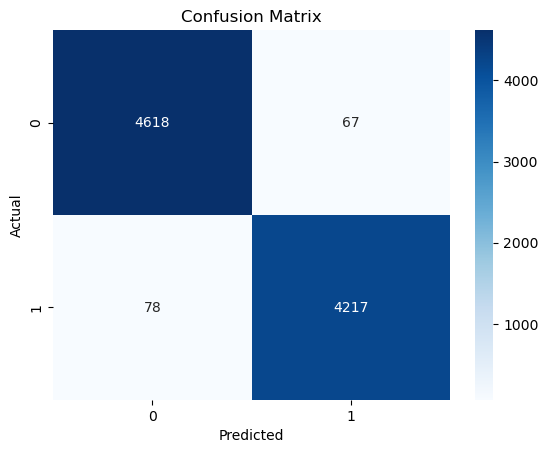

In [31]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

## Testing Custom News Input

The trained model is tested using a custom news sentence entered by the user.

In [33]:
news = ["The government announced free laptops for all students next month"]

news_vec = vectorizer.transform(news)

prediction = model.predict(news_vec)

if prediction[0] == 1:
    print("Real News")
else:
    print("Fake News")

Fake News


# Conclusion

The Fake News Detection system was successfully developed using NLP and Machine Learning techniques.

The project demonstrates:
- Text preprocessing
- TF-IDF feature extraction
- Logistic Regression classification
- Data visualization
- Model evaluation

The model achieved high accuracy in detecting fake and real news articles.